# Celltype Classification with Transcriptformer

This notebooks showcases how the Transcriptformer embeddings can be used to train a classifier for celltype classification across species.

In this notebook, we will show how transcriptformer can be used to transfer cell type annotation from one species to another. We will be using the spermatogenesis scRNA-seq data from [Murat et al.](https://www.nature.com/articles/s41586-022-05547-7).

This is a partial analysis, similar to the one reported in the paper, in Figure 3.

First, we'll import some useful libraries.

In [6]:
%load_ext autoreload
%autoreload 2

import warnings
import os

# Suppress all warnings
warnings.filterwarnings('ignore')

# Import the Python client
from transcriptformer import TranscriptFormerClient

import pandas as pd
import numpy as np
import seaborn as sns
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Model and Data Setup

 In this updated notebook, we use the **TranscriptFormer Python client** (`tf`) which provides a intuitive interface for downloading relevant data, model artifacts and running inference.

In [2]:
# Create TranscriptFormer client for downloads and inference
tf = TranscriptFormerClient()
save_dir = "./checkpoints"

We will be using the **`tf-exemplar`** model, trained on 5 model organisms. The model checkpoints and associated artifacts are approximately **4.2GB** in total for this model variant.

Since the species we will be showing in this notebook (*Rhesus macaque* and *Marmoset*) are **out-of-distribution** species for the model (the model was not trained on scRNA-seq data from those species), we will also need to download the ESM2 gene embeddings:
- Embeddings tar file: ~4.8GB
- Uncompressed: ~5GB

The Python client handles all downloads automatically with progress indicators.

In [3]:
# Download embeddings using the client
print("📦 Downloading embeddings...")
tf.download_model('all-embeddings', checkpoint_dir=save_dir)
print("✅ Embeddings downloaded!")

# Download the tf-exemplar model using the client
print("📦 Downloading tf-exemplar model...")
tf.download_model('tf-exemplar', checkpoint_dir=save_dir)
print("✅ tf-exemplar model downloaded!")

📦 Downloading embeddings...
Extracting all_embeddings...
Extracting all_embeddings |##################################################| 100% 

Successfully downloaded and extracted all_embeddings to checkpoints/all_embeddings
✅ Embeddings downloaded!
📦 Downloading tf-exemplar model...
Extracting tf_exemplar...
Extracting tf_exemplar |##################################################| 100% 

Successfully downloaded and extracted tf_exemplar to checkpoints/tf_exemplar
✅ tf-exemplar model downloaded!



However, one can equivalently use the CLI
```bash
# Downloads
transcriptformer download tf-exemplar
transcriptformer download all-embeddings


We will also download the data. We provide a utility function to download the processed dataset: `bgee_testis_evolution`. It accepts as argument the species name and the file path where it should be saved. Here, we will use *Macaque* to learn a cell type classifier, and transfer the celltypes to *Marmoset*. It should be noted that both of the species were not used in training, demonstrating ability to generalize across the tree of life.

In [3]:
# Download the data using the unified client interface
# We will load the data directly into memory since it is small
adata = tf.download_dataset('bgee-testis-evolution', organism='macaque')

We can then run inference on the data.

In [4]:
checkpoint_path = os.path.join(save_dir, "tf_exemplar")
macaque_embedding_path = os.path.join(save_dir, "all_embeddings/macaca_mulatta_gene.h5")

# Run inference using the Python client - much simpler!
adata_output = tf.inference(
    data_file=adata,  # Can pass AnnData object directly
    checkpoint_path=checkpoint_path,
    pretrained_embedding=macaque_embedding_path
)

Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 950/950 [02:04<00:00,  7.62it/s]


We will now also embed the dataset that we want to map celltypes to. In this case, the *Marmoset* dataset. We will download the data first and then run inference with the model to get the embeddings.

In [5]:
# Download marmoset data using the unified client interface
adata_map = tf.download_dataset('bgee-testis-evolution', organism='marmoset')

# Run inference on marmoset data with different pretrained embedding
marmoset_embedding_path = os.path.join(save_dir, "all_embeddings/callithrix_jacchus_gene.h5")
adata_map_output = tf.inference(
    data_file=adata_map,
    checkpoint_path=checkpoint_path,
    pretrained_embedding=marmoset_embedding_path
)

Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting DataLoader 0: 100%|██████████| 797/797 [01:41<00:00,  7.89it/s]


Next, we can train a classifier to predict the cell type labels. We will train the classifier on the first dataset (*Macaque*) and then use it to predict the cell type labels on the second dataset (*Marmoset*).

In [ ]:
pipeline = Pipeline(
                [
                    #("scaler", StandardScaler()),
                    ("knn", KNeighborsClassifier()),
                ]
            )

embeddings, labels = adata_output.obsm["embeddings"], adata_output.obs["cell_type"]
embeddings_map = adata_map_output.obsm["embeddings"]
pipeline.fit(embeddings, labels)
classes = pipeline.predict(embeddings_map)

The knn classifier is trained on the macaque data and used to predict the cell types in the marmoset data. The predicted cell types are stored in the `predicted_cell_type` column of the `obs` attribute of the AnnData object. The UMAP embedding is computed using the `transcriptformer_embedding` representation.

In [19]:
adata_map.obs['predicted_cell_type'] = pd.Categorical(classes)
adata_map.obsm["transcriptformer_embedding"] = embeddings_map
sc.pp.neighbors(adata_map, use_rep="transcriptformer_embedding")
sc.tl.umap(adata_map)

We can then plot the predicted cell type labels on the second dataset. We will compute UMAP embeddings using the transcriptformer embeddings and plot the results.
The knn classifier seems to have transferred the cell types from one species to the other correctly.

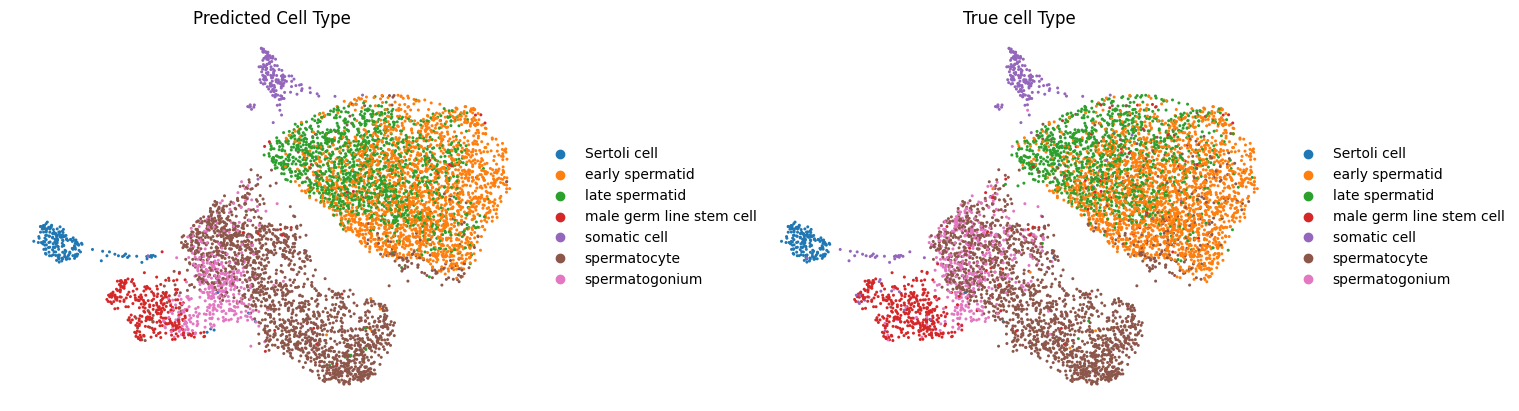

In [20]:
sc.pl.umap(
    adata_map, 
    color=['predicted_cell_type', "cell_type"], 
    ncols=2, 
    frameon=False,
    wspace=0.3,  # Add space between plots
    title=['Predicted Cell Type', 'True cell Type'],  # Add descriptive titles
)

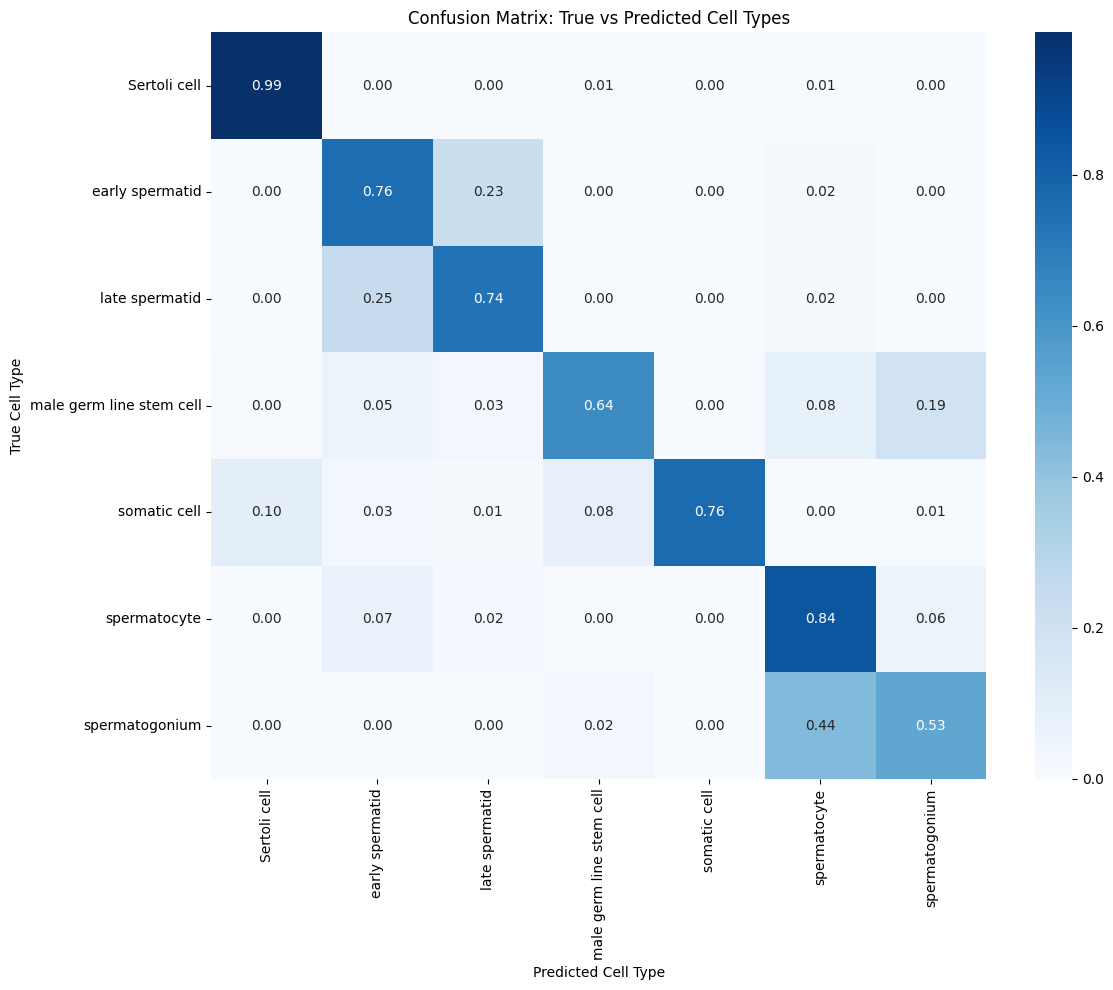

In [22]:
true_labels = adata_map.obs['cell_type']
pred_labels = adata_map.obs['predicted_cell_type']

# Get unique labels from both true and predicted
all_labels = np.unique(np.concatenate([true_labels.cat.categories, pred_labels.cat.categories]))

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=all_labels)

# Normalize the confusion matrix by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel('Predicted Cell Type')
plt.ylabel('True Cell Type')
plt.title('Confusion Matrix: True vs Predicted Cell Types')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

We can also visualize that using a confusion matrix between predicted and true cell types.

We can finally plot the embeddings of both datasets in the same UMAP space.

... storing 'barcodes' as categorical
... storing 'experiment_id' as categorical
... storing 'library_id' as categorical
... storing 'anatEntityId' as categorical
... storing 'anatEntityName' as categorical
... storing 'anatEntityAuthorAnnotation' as categorical
... storing 'stageId' as categorical
... storing 'stageName' as categorical
... storing 'stageAuthorAnnotation' as categorical
... storing 'cellTypeId' as categorical
... storing 'cellTypeName' as categorical
... storing 'cellTypeAuthorAnnotation' as categorical
... storing 'strain' as categorical
... storing 'sex' as categorical
... storing 'rnaSeqSequencerName' as categorical
... storing 'libraryType' as categorical
... storing 'cellCompartment' as categorical
... storing 'cell_type' as categorical
... storing 'organism' as categorical
... storing 'tissue' as categorical
... storing 'suspension_type' as categorical
... storing 'dataset_id' as categorical
... storing 'assay' as categorical
... storing 'assay_ontology_term_id' 

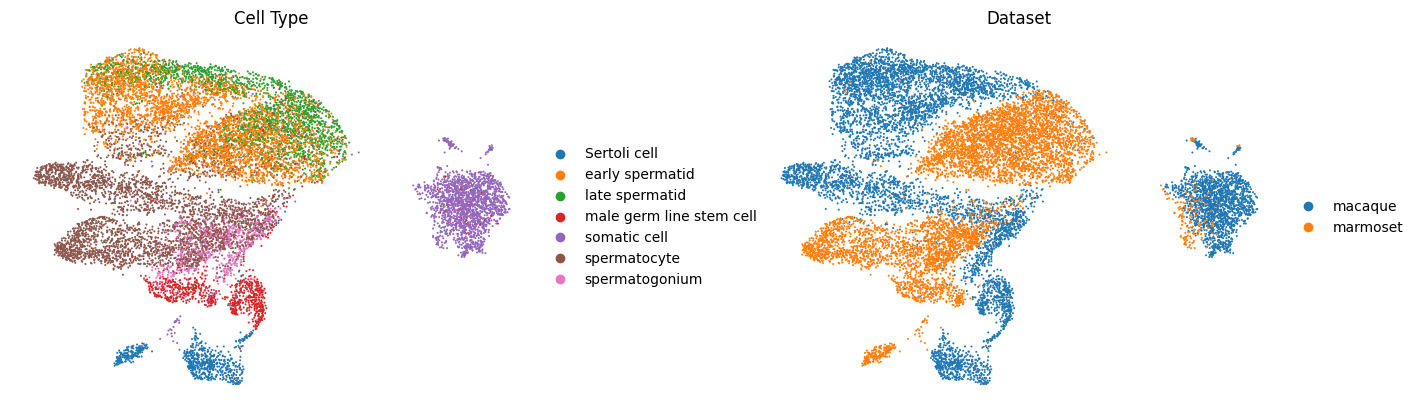

In [23]:
# Concatenate the AnnData objects
adata_joint = ad.concat(
    [adata_output, adata_map_output], 
    label="dataset", 
    keys=["macaque", "marmoset"], 
)

# Perform UMAP and plot
sc.pp.neighbors(adata_joint, use_rep="embeddings")
sc.tl.umap(adata_joint)
sc.pl.umap(
    adata_joint, 
    color=["cell_type", "dataset"], 
    ncols=2, 
    frameon=False,
    wspace=0.3,  # Add space between plots
    title=['Cell Type', 'Dataset'],  # Add descriptive titles
)